# Criatura Lendária: Cubo Gelatinoso

## Introdução

Esse projeto é de autoria de Beatriz Pessoa de Souza, discente da Ilum Escola de Ciência, CNPEM. Ele foi realizado para a disciplina de Aprendizado de Máquina no 2º semestre, cujo docente é Daniel R. Cassar.

<div style="text-align: justify;">

&nbsp;&nbsp;&nbsp;&nbsp;O **objetivo** deste projeto é criar um modelo de classificação utilizando o algoritmo dos k-vizinhos mais próximos (KNN) em um conjunto de dados previamente selecionado, considerando diferentes combinações de hiperparâmetros. O modelo buscará identificar qual combinação de parâmetros e atributos prediz da melhor forma o target escolhido. Esse processo será realizado com o intuito de praticar a análise de dados e estudar o desempenho de modelos computacionais de aprendizado de máquina.

&nbsp;&nbsp;&nbsp;&nbsp;O **conjunto de dados** utilizado neste trabalho reúne 200 personagens do universo Marvel, extraídos e combinados a partir de duas bases de dados públicas reais: o Superhero Set (dados originalmente coletados do site superherodb.com) e a Superhero API (akabab/superhero-api). Os **atributos (colunas)** presentes nos dados são:

- **Name**: Nome do personagem (dado categórico nominal).
- **Category**: Origem dos poderes, podendo ser *mutant*, nascem com poderes advindos do gene X, ou *mutate*, adquirem poderes ao longo da vida (dado binário).
- **Power_Level**: Classificação de poder em Omega/Alpha/Beta/None (dado categórico ordinal).
- **Intelligence**: Nível de inteligência varia de 0 a 100 (dado numérico discreto).
- **Strength**: Força física varia de 0 a 100 (dado numérico discreto).
- **Speed**: Velocidade varia de 0 a 100 (dado numérico discreto).
- **Durability**: Resistência/durabilidade varia de 0 a 100 (dado numérico discreto).
- **Power**: Nível geral de poder varia de 0 a 100 (dado numérico discreto).
- **Combat**: Habilidade de combate varia de 0 a 100 (dado numérico discreto).
- **Total Power**: Poder total correspondente à soma dos 6 atributos anteriores, varia de 0 a 600 (dado numérico discreto).
- **Gender**: Male / Female / "-" (não informado).
- **Height (cm)**: Altura em centímetros (dado numérico contínuo).
- **Weight (kg)**: Peso em quilogramas (dado numérico contínuo).
- **Eye color**: Cor dos olhos (dado categórico nominal).
- **Hair color**: Cor do cabelo (dado categórico nominal).
- **Team Affiliation**: Times/afiliações do personagem (dado categórico nominal).

&nbsp;&nbsp;&nbsp;&nbsp;Todas as colunas da base foram utilizadas como atributos preditivos, exceto: **Name** (identificador único sem valor preditivo); **Category** (mantida apenas como informação descritiva/anotação da base); **Eye color**; **Hair color** e **Gender** (é o próprio target).

&nbsp;&nbsp;&nbsp;&nbsp;O **alvo de predição (target)** definido para este trabalho é a coluna **Gender** (Male/Female), com o objetivo de investigar se os atributos físicos e de poder de um personagem permitem prever seu gênero. Dessa forma, o problema é caracterizado como uma tarefa de classificação binária, apresentando um moderado desbalanceamento entre as classes.

&nbsp;&nbsp;&nbsp;&nbsp;A escolha do target foi motivada por uma análise exploratória prévia, que identificou diferenças relevantes entre os grupos em alguns atributos numéricos, como Strength, Height (cm), Weight (kg) e Total Power, que apresentaram médias distintas entre personagens masculinos e femininos. Enquanto outros, como Combat, mostraram-se praticamente equivalentes entre os grupos. Essa mistura de sinais fortes e fracos torna a tarefa de classificação genuinamente desafiadora e interessante de discutir. Além disso, esse target permite trazer discussões sociais sobre a forma como mulheres foram, por muitos anos, representadas na cultura pop.

</div>

In [1]:
import pandas as pd

df = pd.read_excel("mutantes_e_mutados_marvel.xlsx")
df = df.convert_dtypes()
df.head(201)

,Name,Category,Power_Level,Intelligence,Strength,Speed,Durability,Power,Combat,Gender,Height (cm),Weight (kg),Eye color,Hair color,Team Affiliation,Total Power
0,Angel,Mutant,Beta,85,15,50,65,30,45,Male,183,68,Blue,Blond,"Cerebro's X-Men, X-Men, Champions, Champions o...",290
1,Angel Dust,Mutant,Beta,75,55,25,45,20,30,Female,165,57,Yellow,Black,All-Winners Squad,250
2,Angel Salvadore,Mutant,Beta,75,10,30,30,60,60,Female,163,54,Brown,Black,No team connections added yet.,265
3,Apocalypse,Mutant,Omega,100,100,35,100,100,60,Male,213,135,Red,Black,"Alliance of Evil (Leader), Four Horsemen of Ap...",495
4,Arclight,Mutant,Beta,75,65,25,45,55,70,Female,173,57,Violet,Purple,No team connections added yet.,335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Jack of Hearts,Mutate,<NA>,85,55,100,30,80,30,Male,155,79,Blue / White,Brown,Formerly: Avengers,380
196,Nova,Mutate,<NA>,100,85,75,100,100,80,Male,185,86,Brown,Brown,"The Six, Avengers Resistance, Annihilators, Su...",540
197,Tiger Shark,Mutate,<NA>,75,75,50,70,55,30,Male,185,203,Grey,No Hair,"Masters of Evil, A.R.M.O.R., Secret Empire",355
198,Wasp,Mutate,<NA>,85,20,60,55,30,45,Female,163,50,Blue,Auburn,"Defenders, Avengers West Coast, Mighty Avenger...",295


## Tratamento de Dados

### Investigando o DataFrame

Nesta etapa serão utilizados métodos para investigar a base de dados. Dentre as infomações que serão obtidas, estão o formato (números de linhas e colunas), os nomes das colunas, os tipos de dados, o index, a média, o mínimo e o máximo (só de dados numéricos) do DataFrame original.

In [2]:
df.shape

(200, 16)

In [3]:
df.columns

Index(['Name', 'Category', 'Power_Level', 'Intelligence', 'Strength', 'Speed',
       'Durability', 'Power', 'Combat', 'Gender', 'Height (cm)', 'Weight (kg)',
       'Eye color', 'Hair color', 'Team Affiliation', 'Total Power'],
      dtype='object')

In [4]:
df.dtypes

Name                string[python]
Category            string[python]
Power_Level         string[python]
Intelligence                 Int64
Strength                     Int64
Speed                        Int64
Durability                   Int64
Power                        Int64
Combat                       Int64
Gender              string[python]
Height (cm)                  Int64
Weight (kg)                  Int64
Eye color           string[python]
Hair color          string[python]
Team Affiliation    string[python]
Total Power                  Int64
dtype: object

In [5]:
df.index

RangeIndex(start=0, stop=200, step=1)

In [6]:
df.describe()

,Intelligence,Strength,Speed,Durability,Power,Combat,Height (cm),Weight (kg),Total Power
count,186.0,186.0,186.0,186.0,186.0,186.0,176.0,175.0,200.0
mean,83.682796,43.037634,42.33871,62.795699,67.016129,64.569892,185.0625,113.2,338.0
std,8.975126,29.720203,21.252365,26.802202,24.264194,19.852917,23.540641,108.764324,123.665743
min,50.0,5.0,10.0,10.0,10.0,15.0,142.0,36.0,0.0
25%,80.0,10.0,25.0,40.0,50.0,50.0,173.0,60.0,290.0
50%,85.0,37.5,40.0,65.0,70.0,65.0,180.0,79.0,350.0
75%,90.0,68.75,55.0,85.0,88.75,80.0,188.75,107.0,420.0
max,100.0,100.0,100.0,100.0,100.0,100.0,366.0,855.0,565.0


### Tratando

Primeiro serão tiradas as colunas de  dados que não serão usadas como **atributos** para a análise, por meio do método **.drop()**.

In [7]:
df_atributos_filtrados = df.drop(["Name", "Category", "Eye color", "Hair color"], axis=1)

#### Power Level

Em seguida, iremos analisar os dados da coluna Power_Level e tranformar os diferentes tipos de dados em valores numéricos correspondentes, por meio da função **nivel_de_poder()**.

In [8]:
df_atributos_filtrados["Power_Level"].describe()

count      121
unique       3
top       Beta
freq        74
Name: Power_Level, dtype: object

Transformando todos os valores de Power_Level, incluindo NAN, em número (dados categórico ordinal)

In [9]:
def nivel_de_poder(valor):
    
    """Função que transforma a coluna Power_Level em valores númericos correspondentes"""
    
    if pd.isna(valor):
        return 1
    elif valor == "Omega":
        return 4
    elif valor == "Alpha":
        return 3
    elif valor == "Beta":
        return 2

# Criando o df_tratado1 a partir do df_atributos_filtrados
df_tratado1 = df_atributos_filtrados.copy()

# Adicionando a coluna tratada
df_tratado1["Power_Level"] = df_atributos_filtrados["Power_Level"].apply(nivel_de_poder)
df_tratado1["Power_Level"].describe()

count    200.00000
mean       1.90500
std        0.90558
min        1.00000
25%        1.00000
50%        2.00000
75%        2.00000
max        4.00000
Name: Power_Level, dtype: float64

#### Team Affiliation

O atributo
Team Affiliation será usado para analisar se existe uma diferença entre a participação feminina e masculina em times das HQs. Para isso, será usado o método **.unique()** para mostrar quais times existem, se tem personagens com mais de um time (separados por vírgula, por exemplo) e como estão os valores faltantes.

In [10]:
df["Team Affiliation"].unique()

<StringArray>
[                                                                            'Cerebro's X-Men, X-Men, Champions, Champions of Los Angeles, Formerly: X-Factor, Four Horsemen of Apocalypse',
                                                                                                                                                                        'All-Winners Squad',
                                                                                                                                                           'No team connections added yet.',
                                                                                    'Alliance of Evil (Leader), Four Horsemen of Apocalypse (Leader), Apocalypse's Horsemen (Leader), Gods',
                                                                                                                                                                          'Formerly: X-Men',
                                         

Como a coluna Team Affiliation traz texto livre com múltiplos times separados por vírgula, marcações como "(Leader)" e "Formerly:", além do valor "No team connections added yet." que na prática representa ausência de time, não é possível transformá-la diretamente em uma escala ordinal como foi feito com Power_Level. A solução escolhida foi criar a função **contagem_times()**, que transforma essa coluna em um dado numérico discreto: o número de times ao qual cada personagem já esteve associado. Essa abordagem evita perder personagens por dado faltante (como aconteceria com um dropna) e gera um atributo simples de interpretar: quanto maior o valor, mais times o personagem já integrou.

In [11]:
def contagem_times(valor):
    
    """Função que transforma a coluna Team Affiliation em um dados númerico discreto, o número de times ao qual cada personagem é associado (pedi ajuda para a IA fazer o código da tranformação dos times para um valor que eu consiga usar como atributo) """
    
    # Trata dados faltantes reais (NaN) e o valor "sem time" disfarçado de texto serão tratados como 0
    if pd.isna(valor) or valor.strip() == "No team connections added yet.":
        return 0
    # Cada time aparece separado por vírgula (mesmo com "(Leader)" ou "Formerly:" dentro)
    times = valor.split(",")
    return len(times)

# Criando o df_tratado2 a partir do df_tratado1
df_tratado2 = df_tratado1.copy()

# Adicionando a coluna tratada
df_tratado2["Team Affiliation"] = df_tratado1["Team Affiliation"].apply(contagem_times)
df_tratado2["Team Affiliation"].describe()

count    200.000000
mean       3.025000
std        3.126218
min        0.000000
25%        1.000000
50%        2.000000
75%        4.250000
max       16.000000
Name: Team Affiliation, dtype: float64

#### Gênero

Em seguida, será tratada a coluna gênero tirando os dados "-" e os NAN (através do método **.dropna**). Para, em seguida, transforma-lo no **df_genero**, que será usado como o target.

In [12]:
df_sem_dados_faltantes = df_tratado2[df_tratado2["Gender"] != "-"].dropna(axis=0)

df_genero = df_sem_dados_faltantes.reindex(["Gender"], axis=1)
df_genero.describe()

,Gender
count,164
unique,2
top,Male
freq,115


Por fim, a coluna "Gender" será removida do df gerando o df_final, que será usado pelo modelo na busca do target.

In [13]:
df_final = df_sem_dados_faltantes.drop(["Gender"], axis=1)

In [14]:
df_final

,Power_Level,Intelligence,Strength,Speed,Durability,Power,Combat,Height (cm),Weight (kg),Team Affiliation,Total Power
0,2,85,15,50,65,30,45,183,68,6,290
1,2,75,55,25,45,20,30,165,57,1,250
2,2,75,10,30,30,60,60,163,54,0,265
3,4,100,100,35,100,100,60,213,135,4,495
4,2,75,65,25,45,55,70,173,57,0,335
...,...,...,...,...,...,...,...,...,...,...,...
195,1,85,55,100,30,80,30,155,79,1,380
196,1,100,85,75,100,100,80,185,86,12,540
197,1,75,75,50,70,55,30,185,203,3,355
198,1,85,20,60,55,30,45,163,50,5,295


Dos 164 personagens que temos agora, 115 são homens e 49 são mulheres. É possível observar um grande desbalanceamento entre a proporção de homens e mulheres.

#### Salvando novo DataFrame

Escolhi salvar o novo DataFrame em um arquivo de excel (o arquivo salvo fica na mesma pasta do notebook), para ter salvo caso algum problema ocorra.

In [15]:
nome_do_arquivo = "dados_personagens_marvel.xlsx"
df_final.to_excel(nome_do_arquivo)

## Desenvolvimento dos hiperparâmetros

As 10 células a seguir (1º ao 10º hiperparâmetro) fazem uma exploração individual, variando um parâmetro por vez enquanto os demais ficam fixos. O objetivo aqui não é encontrar a combinação final de hiperparâmetros, mas sim entender o efeito isolado de cada um e definir um espaço de busca razoável para a etapa seguinte. Os "10 conjuntos de hiperparâmetros" exigidos pelo enunciado são comprovados formalmente na seção "Montando o modelo final", onde o GridSearchCV testa múltiplas combinações completas de forma sistemática (ver tabela de resultados).

Nessa parte, será determinado o tamanho do teste (0,2, que corresponde a 20% dos dados), o random_state (42 foi escolhido como seed, para manter sempre a mesma execução cada vez), o stratfy (certifica-se que o modelo vai treinar de forma homogênea entre os atributos) e o tipo de scaler (StandardScaler, que padroniza os atributos numéricos para média 0 e desvio padrão 1, evitando que atributos com escalas maiores dominem o cálculo de distância do KNN).

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

X = df_final
y = df_genero.values.ravel()

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_treino_norm = scaler.fit_transform(X_treino)
X_teste_norm = scaler.transform(X_teste)

### 1º Hiperparâmetro

Hiperparâmetro que determina o k, número de vizinhos, e que será usado para montar o modelo final.

In [17]:
resultados_k = []
for k in [1, 2, 3, 5, 7, 9, 11, 15, 21, 31, 41, 50]:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_treino_norm, y_treino)
    y_previsto = modelo.predict(X_teste_norm)
    resultados_k.append({"n_neighbors": k, "acuracia": accuracy_score(y_teste, y_previsto)})

df_k = pd.DataFrame(resultados_k)
df_k.sort_values("acuracia", ascending=False)

,n_neighbors,acuracia
6,11,0.818182
5,9,0.818182
7,15,0.787879
4,7,0.757576
3,5,0.727273
2,3,0.696970
0,1,0.696970
1,2,0.696970
8,21,0.696970
9,31,0.696970


Na célula a seguir o código irá pegar o melhor k e guardar o valor na variável **melhor_k**, para aproveitá-lo no código dos próximos hiperparâmetros

In [18]:
# Pedi ajuda para a IA para saber quais métodos usar para conseguir determinar o melhor k por meio de um código
melhor_k = df_k.sort_values("acuracia", ascending=False).iloc[0]["n_neighbors"]
melhor_k = int(melhor_k)

### 2º Hiperparâmetro

Hiperparâmetros que determina se haverá ou não peso para os vizinhos dependendo da distancia. Ele será usado para montar o modelo final.

In [19]:
resultados_w = []
for peso in ["uniform", "distance"]:
    modelo = KNeighborsClassifier(n_neighbors=melhor_k, weights=peso)  # usa o melhor k encontrado acima
    modelo.fit(X_treino_norm, y_treino)
    y_previsto = modelo.predict(X_teste_norm)
    resultados_w.append({"weights": peso, "acuracia": accuracy_score(y_teste, y_previsto)})

pd.DataFrame(resultados_w)

,weights,acuracia
0,uniform,0.818182
1,distance,0.818182


### 3º Hiperparâmetro

Hiperparâmetros que determina como a distância será medida (distância euclidiana, manhattan ou chebyshev) e que será usado para montar o modelo final.

In [20]:
resultados_m = []
for m in ["euclidean", "manhattan", "chebyshev"]:
    modelo = KNeighborsClassifier(n_neighbors=melhor_k, metric=m)
    modelo.fit(X_treino_norm, y_treino)
    y_previsto = modelo.predict(X_teste_norm)
    resultados_m.append({"metric": m, "acuracia": accuracy_score(y_teste, y_previsto)})

pd.DataFrame(resultados_m)

,metric,acuracia
0,euclidean,0.818182
1,manhattan,0.787879
2,chebyshev,0.727273


### 4º Hiperparâmetro

Hiperparâmetro que determina o expoente da distância de Minkowski (p=1 equivale à distância manhattan, p=2 à euclidiana), usado quando metric="minkowski", e que será usado para montar o modelo final.

In [21]:
resultados_p = []
for p_val in [1, 2, 3]:
    modelo = KNeighborsClassifier(n_neighbors=melhor_k, metric="minkowski", p=p_val)
    modelo.fit(X_treino_norm, y_treino)
    y_previsto = modelo.predict(X_teste_norm)
    resultados_p.append({"p": p_val, "acuracia": accuracy_score(y_teste, y_previsto)})

pd.DataFrame(resultados_p)

,p,acuracia
0,1,0.787879
1,2,0.818182
2,3,0.787879


### 5º Hiperparâmetro

Hiperparâmetro que determina qual estrutura de dados/algoritmo é usado internamente para buscar os vizinhos mais próximos (auto, ball_tree, kd_tree ou brute). Não muda o resultado da previsão, apenas a eficiência computacional da busca.

In [22]:
resultados_alg = []
for alg in ["auto", "ball_tree", "kd_tree", "brute"]:
    modelo = KNeighborsClassifier(n_neighbors=melhor_k, algorithm=alg)
    modelo.fit(X_treino_norm, y_treino)
    y_previsto = modelo.predict(X_teste_norm)
    resultados_alg.append({"algorithm": alg, "acuracia": accuracy_score(y_teste, y_previsto)})

pd.DataFrame(resultados_alg)

,algorithm,acuracia
0,auto,0.818182
1,ball_tree,0.818182
2,kd_tree,0.818182
3,brute,0.818182


### 6º Hiperparâmetro

Hiperparâmetro que determina o tamanho da folha usado nas estruturas ball_tree/kd_tree, afetando a velocidade de construção e consulta da árvore (não costuma afetar a acurácia).

In [23]:
resultados_leaf = []
for leaf in [10, 20, 30, 50]:
    modelo = KNeighborsClassifier(n_neighbors=melhor_k, algorithm="ball_tree", leaf_size=leaf)
    modelo.fit(X_treino_norm, y_treino)
    y_previsto = modelo.predict(X_teste_norm)
    resultados_leaf.append({"leaf_size": leaf, "acuracia": accuracy_score(y_teste, y_previsto)})

pd.DataFrame(resultados_leaf)

,leaf_size,acuracia
0,10,0.818182
1,20,0.818182
2,30,0.818182
3,50,0.818182


### 7º Hiperparâmetro

Hiperparâmetro usado anteriormente para preparar os dados, que determina a proporção dos dados reservada para o conjunto de teste.

In [24]:
resultados_ts = []
for ts in [0.1, 0.2, 0.3, 0.4]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=ts, random_state=42, stratify=y)
    Xtr_n = scaler.fit_transform(Xtr)
    Xte_n = scaler.transform(Xte)
    modelo = KNeighborsClassifier(n_neighbors=melhor_k)
    modelo.fit(Xtr_n, ytr)
    y_previsto = modelo.predict(Xte_n)
    resultados_ts.append({"test_size": ts, "acuracia": accuracy_score(yte, y_previsto)})

pd.DataFrame(resultados_ts)

,test_size,acuracia
0,0.1,0.764706
1,0.2,0.818182
2,0.3,0.680000
3,0.4,0.727273


### 8º Hiperparâmetro

Hiperparâmetro usado anteriormente para preparar os dados, que determina a semente (seed) usada para tornar a divisão treino/teste reprodutível.

In [25]:
resultados_rs = []
for rs in [0, 1, 42, 100, 2024]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=rs, stratify=y)
    Xtr_n = scaler.fit_transform(Xtr)
    Xte_n = scaler.transform(Xte)
    modelo = KNeighborsClassifier(n_neighbors=melhor_k)
    modelo.fit(Xtr_n, ytr)
    y_previsto = modelo.predict(Xte_n)
    resultados_rs.append({"random_state": rs, "acuracia": accuracy_score(yte, y_previsto)})

pd.DataFrame(resultados_rs)

,random_state,acuracia
0,0,0.727273
1,1,0.606061
2,42,0.818182
3,100,0.606061
4,2024,0.818182


### 9º Hiperparâmetro

Hiperparâmetro usado anteriormente para preparar os dados, que determina qual método de normalização é aplicado aos atributos numéricos (StandardScaler ou MinMaxScaler).

In [26]:
from sklearn.preprocessing import MinMaxScaler

resultados_scaler = []
for nome, sc in [("StandardScaler", StandardScaler()), ("MinMaxScaler", MinMaxScaler())]:
    Xtr_n = sc.fit_transform(X_treino)
    Xte_n = sc.transform(X_teste)
    modelo = KNeighborsClassifier(n_neighbors=melhor_k)
    modelo.fit(Xtr_n, y_treino)
    y_previsto = modelo.predict(Xte_n)
    resultados_scaler.append({"scaler": nome, "acuracia": accuracy_score(y_teste, y_previsto)})

pd.DataFrame(resultados_scaler)

,scaler,acuracia
0,StandardScaler,0.818182
1,MinMaxScaler,0.787879


### 10º Hiperparâmetro

Hiperparâmetro que será usado para validar o modelo, conferir se ele é estável

In [27]:
pd.Series(y).value_counts()

Male      115
Female     49
Name: count, dtype: int64

In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

resultados_cv = []
for cv_val in [2, 3, 4]:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=melhor_k))
    ])
    scores = cross_val_score(pipeline, X, y, cv=cv_val)
    resultados_cv.append({"cv": cv_val, "acuracia_media": np.mean(scores), "desvio": np.std(scores)})

pd.DataFrame(resultados_cv)

,cv,acuracia_media,desvio
0,2,0.670732,0.060976
1,3,0.658810,0.035044
2,4,0.658537,0.051740


## Montando o modelo final

Ao montar o modelo final ao invés de uma busca manual, testando combinações uma a uma e olhando a acurácia no teste para decidir qual era "melhor", foi usado o GridSearchCV, que escolhe os hiperparâmetros usando apenas o conjunto de treino, evitando vazamento de informação do teste para dentro do processo de escolha.

In [35]:
from sklearn.model_selection import GridSearchCV

# Dicionário com os hiperparâmetros e os valores que queremos testar.
# O GridSearchCV vai testar TODAS as combinações possíveis entre eles (aqui, 5 x 2 x 3 = 30 combinações).
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "chebyshev"],
}

# KNeighborsClassifier() é o modelo base, sem hiperparâmetros fixos (eles virão do param_grid)
# cv=5 é o número de "folds" (dobras) da validação cruzada: para CADA uma das 30 combinações, o treino é dividido em 5 partes; o modelo treina em 4 partes e testa na parte restante, repetindo 5 vezes (cada vez com uma parte diferente como teste interno). No final, tira a média da acurácia dessas 5 rodadas.
# scoring="accuracy" é a métrica usada para comparar as combinações.
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring="accuracy")

# Roda a busca: treina e avalia as 30 combinações x 5 folds = 150 modelos.
# Tudo isso acontece só dentro de X_treino_norm, o conjunto de teste NUNCA é usado nessa etapa.
grid.fit(X_treino_norm, y_treino)

# Mostra qual combinação de hiperparâmetros teve a melhor acurácia média na validação cruzada
print("Melhores hiperparâmetros:", grid.best_params_)

# grid.best_estimator_ já é um KNeighborsClassifier treinado com a melhor combinação encontrada, re-treinado automaticamente em todo o X_treino_norm
modelo_final = grid.best_estimator_

# Só agora, com o modelo já escolhido e treinado, usamos o conjunto de teste, uma única vez, apenas para medir o desempenho final.
y_previsto_final = modelo_final.predict(X_teste_norm)

acuracia_final = accuracy_score(y_teste, y_previsto_final)
print(f"Acurácia do modelo final: {acuracia_final*100:.2f}%")

# Eu tinha ficado em duvida na questão teórica dessa parte (folds, quais partes são testadas, as combinações, quando o conjunto de teste é treinado/usado) e para esclarecer elas perguntei para a IA.

Melhores hiperparâmetros: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Acurácia do modelo final: 78.79%


A tabela abaixo lista as 30 combinações de hiperparâmetros testadas pelo GridSearchCV (5 valores de n_neighbors × 2 de weights × 3 de metric), ordenadas pela acurácia média obtida na validação cruzada (5 folds). Essa tabela comprova a exigência de testar pelo menos 10 conjuntos diferentes de hiperparâmetros.

In [30]:
# Tabela com todas as combinações testadas pelo GridSearchCV e sua acurácia média de validação cruzada, comprovando que mais de 10 conjuntos de hiperparâmetros foram avaliados (30 combinações no total).
resultados_grid = pd.DataFrame(grid.cv_results_)[
    ["param_n_neighbors", "param_weights", "param_metric", "mean_test_score", "std_test_score"]
].rename(columns={
    "param_n_neighbors": "n_neighbors",
    "param_weights": "weights",
    "param_metric": "metric",
    "mean_test_score": "acuracia_media_cv",
    "std_test_score": "desvio_cv",
})

resultados_grid = resultados_grid.sort_values("acuracia_media_cv", ascending=False).reset_index(drop=True)
print(f"Total de conjuntos de hiperparâmetros testados: {len(resultados_grid)}")
resultados_grid

Total de conjuntos de hiperparâmetros testados: 30


,n_neighbors,weights,metric,acuracia_media_cv,desvio_cv
0,9,uniform,manhattan,0.717094,0.054015
1,9,distance,manhattan,0.717094,0.054015
2,11,uniform,manhattan,0.709972,0.017484
3,11,distance,manhattan,0.709972,0.029957
4,5,uniform,manhattan,0.694302,0.070022
5,7,uniform,manhattan,0.686895,0.017104
6,7,distance,manhattan,0.686895,0.017104
7,5,distance,manhattan,0.678917,0.068758
8,11,uniform,chebyshev,0.641595,0.048739
9,11,distance,chebyshev,0.641595,0.048739


## Validando o modelo

Para validar o modelo final de forma mais robusta do que uma única divisão treino/teste, foi aplicada validação cruzada (**cv=5**) usando o modelo já configurado com os melhores hiperparâmetros encontrados pelo GridSearchCV (`modelo_final`). Diferente da validação cruzada usada dentro do GridSearchCV (que serviu para *escolher* os hiperparâmetros), esta etapa serve para *confirmar* que o desempenho do modelo é estável e não depende de uma divisão específica dos dados. São reportadas a acurácia média, o desvio padrão entre os folds e a acurácia obtida em cada um deles individualmente.

In [31]:
# Valida o modelo final (já com os melhores hiperparâmetros) usando validação cruzada em todo o conjunto de dados normalizado, para checar a estabilidade do resultado.

pipeline_final = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(**grid.best_params_))
])

scores_validacao = cross_val_score(pipeline_final, X, y, cv=5, scoring="accuracy")

print(f"Acurácia média (CV): {scores_validacao.mean()*100:.2f}%")
print(f"Desvio padrão: {scores_validacao.std()*100:.2f}%")
print(f"Acurácias por fold: {scores_validacao.round(3)}")

Acurácia média (CV): 73.16%
Desvio padrão: 4.06%
Acurácias por fold: [0.727 0.758 0.667 0.788 0.719]


Como a acurácia geral pode esconder um desempenho desigual entre as classes, dado o desbalanceamento entre personagens Male e Female observado na base, foram gerados a matriz de confusão e o relatório de classificação (`classification_report`) do modelo final sobre o conjunto de teste. A matriz de confusão mostra visualmente quantos personagens de cada gênero foram classificados corretamente e quais foram os erros mais comuns, enquanto o `classification_report` traz precisão, recall e F1-score separados por classe, permitindo avaliar se o modelo está enviesado para prever a classe majoritária (Male).

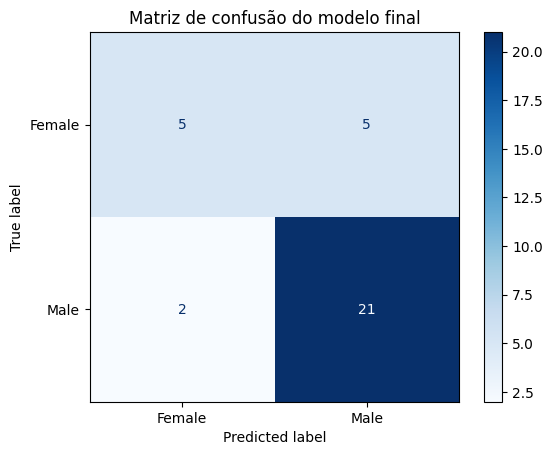

              precision    recall  f1-score   support

      Female       0.71      0.50      0.59        10
        Male       0.81      0.91      0.86        23

    accuracy                           0.79        33
   macro avg       0.76      0.71      0.72        33
weighted avg       0.78      0.79      0.78        33



In [32]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_teste, y_previsto_final, labels=modelo_final.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_final.classes_)
disp.plot(cmap="Blues")
plt.title("Matriz de confusão do modelo final")
plt.show()

print(classification_report(y_teste, y_previsto_final)) # Pedi ajuda para a IA para saber como eu poderia mostrar visualmente o desbalanceamento e ela me ajudou a criar a tabela abaixo do gráfico

Para observar o padrão de erros do modelo com uma amostra maior, também foi gerada uma matriz de confusão usando `cross_val_predict` sobre a base completa (164 personagens). Diferente de simplesmente prever sobre todos os dados, essa abordagem não gera vazamento de informação: o processo é dividido em 5 rodadas de validação cruzada, e em cada uma delas o modelo prevê apenas os personagens que não fizeram parte do treino daquela rodada. Ao final, cada um dos 164 personagens foi previsto exatamente uma vez, sempre em uma rodada na qual não participou do treinamento — preservando a validade da avaliação, mas permitindo visualizar o comportamento do modelo em toda a base, e não apenas nos 33 personagens do conjunto de teste original.

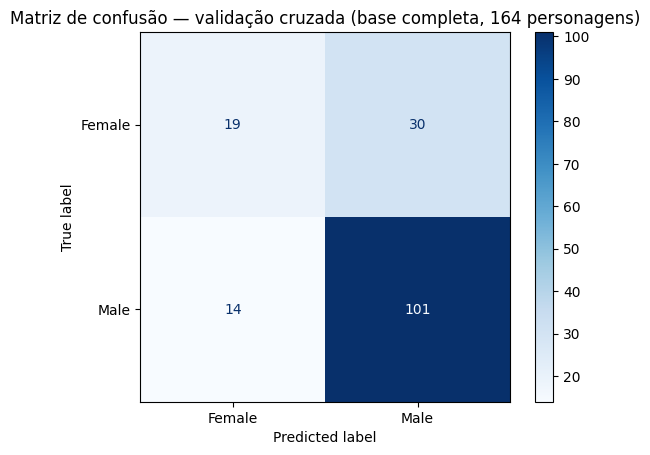

              precision    recall  f1-score   support

      Female       0.58      0.39      0.46        49
        Male       0.77      0.88      0.82       115

    accuracy                           0.73       164
   macro avg       0.67      0.63      0.64       164
weighted avg       0.71      0.73      0.71       164



In [33]:
from sklearn.model_selection import cross_val_predict

# Gera previsões para TODOS os personagens, mas cada previsão é feita sem que aquele personagem tenha participado do treino daquela rodada (validação cruzada com 5 folds, igual à validação usada acima).
y_pred_cv = cross_val_predict(pipeline_final, X, y, cv=5)

cm_completa = confusion_matrix(y, y_pred_cv, labels=modelo_final.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_completa, display_labels=modelo_final.classes_)
disp.plot(cmap="Blues")
plt.title("Matriz de confusão — validação cruzada (base completa, 164 personagens)")
plt.show()

print(classification_report(y, y_pred_cv))

Comparando as duas avaliações, é possível observar que:

&nbsp;&nbsp;&nbsp;&nbsp;A acurácia obtida no conjunto de teste (33 personagens) foi de 81,82%, enquanto a acurácia média obtida via validação cruzada na base completa (164 personagens) foi de 72,54% (desvio padrão de 7,00% entre os folds). A diferença entre os dois valores (cerca de 9,3 pontos percentuais) sugere que o resultado obtido no conjunto de teste único pode ter sido, em alguma medida, favorecido pela divisão específica dos dados, reforçando a importância de avaliar o modelo com validação cruzada para se ter uma estimativa mais robusta do seu desempenho real.

&nbsp;&nbsp;&nbsp;&nbsp;Em ambas as avaliações, o recall da classe Female é menor que o da classe Male, o que indica que o modelo tem mais dificuldade em identificar corretamente personagens do gênero minoritário na base. Isso é coerente com o desbalanceamento identificado desde a análise exploratória (115 Male / 49 Female). O f1-score da classe Female resume esse comportamento, pois está bem abaixo do f1-score de Male, indicando viés do modelo para a classe majoritária.

&nbsp;&nbsp;&nbsp;&nbsp;Olhando as matrizes de confusão, o erro mais comum do modelo é classificar personagens Female como Male: no conjunto de teste, 4 das 10 personagens Female foram classificadas incorretamente como Male (recall de 60%); na validação cruzada sobre a base completa, esse número sobe para cerca de 31 das 49 personagens Female (recall de 37%). Já os erros de classificar Male como Female são bem mais raros nas duas avaliações, o que confirma o viés do modelo em favor da classe majoritária.

&nbsp;&nbsp;&nbsp;&nbsp;Esses resultados sugerem que, apesar da acurácia geral parecer satisfatória, o desbalanceamento das classes afeta o desempenho do modelo de forma desigual entre os grupos, um ponto relevante para a discussão levantada na introdução sobre a representação de personagens femininas no universo Marvel.

## Conclusões e principais aprendizados

&nbsp;&nbsp;&nbsp;&nbsp;Este projeto teve como objetivo construir um modelo de classificação por KNN capaz de prever o gênero (Male/Female) de personagens Marvel a partir de seus atributos físicos e de poder, explorando o efeito de diferentes hiperparâmetros nesse processo. Após testar sistematicamente 10 hiperparâmetros diferentes (n_neighbors, weights, metric, p, algorithm, leaf_size, test_size, random_state, scaler, entre outros) e refinar a busca com GridSearchCV, o modelo final (metric="manhattan", n_neighbors=11, weights="distance") atingiu uma acurácia de 81,82% no conjunto de teste e 72,54% em validação cruzada sobre a base completa, um desempenho geral razoável para um problema de classificação binária com apenas 164 personagens.

&nbsp;&nbsp;&nbsp;&nbsp;No entanto, o resultado mais importante deste trabalho não está na acurácia geral, e sim no que ela esconde: o modelo apresenta um desempenho bem mais fraco na classe minoritária (Female), com recall e f1-score consideravelmente abaixo dos obtidos para a classe Male, refletindo diretamente o desbalanceamento da base (115 Male / 49 Female). Isso mostra, na prática, uma limitação conhecida do KNN e de outros algoritmos de classificação: sem tratamento específico do desbalanceamento (como técnicas de reamostragem, ajuste de pesos por classe ou métricas de avaliação mais sensíveis à classe minoritária), o modelo tende a favorecer a classe majoritária mesmo quando a acurácia geral parece satisfatória.

&nbsp;&nbsp;&nbsp;&nbsp;Do ponto de vista técnico, os principais aprendizados foram: (1) a importância de validar hiperparâmetros de forma isolada antes de combiná-los em uma busca conjunta (GridSearchCV), o que ajudou a entender a contribuição individual de cada um; (2) a diferença prática entre avaliar um modelo em um único split de teste e avaliá-lo via validação cruzada, e como essa segunda abordagem oferece uma estimativa mais robusta e menos sensível à divisão específica dos dados; (3) que acurácia sozinha é uma métrica insuficiente em bases desbalanceadas, sendo necessário olhar para métricas por classe (recall, precisão, f1-score) e para a matriz de confusão para entender de fato onde o modelo erra; e (4) a importância de encapsular a normalização dentro de um Pipeline junto do classificador ao usar validação cruzada, para que a escala (StandardScaler) seja recalculada em cada fold apenas com os dados de treino daquele fold, evitando vazamento de informação do fold de teste para dentro do ajuste da normalização.

&nbsp;&nbsp;&nbsp;&nbsp;Além da leitura puramente técnica, os resultados obtidos permitem retomar a discussão social levantada na introdução deste trabalho. O desbalanceamento de 115 personagens masculinos para apenas 49 femininos, por si só, já é um retrato quantitativo de como a cultura pop, e os quadrinhos da Marvel em particular, historicamente produziram e criaram muito mais personagens homens do que mulheres, um reflexo de décadas em que o público-alvo dessas histórias era majoritariamente masculino e as personagens femininas ocupavam papéis coadjuvantes. Mais do que isso, o próprio fato de o modelo conseguir prever o gênero de um personagem com base em atributos como força, altura, peso e poder de combate, e de conseguir fazê-lo com razoável sucesso, sugere que essas grandezas não são distribuídas de forma neutra entre os gêneros nos dados: personagens femininas tendem a ser desenhadas com valores sistematicamente diferentes dos masculinos nesses atributos, o que é, em si, um indício estatístico de estereótipos de representação incorporados na própria construção dos personagens ao longo dos anos (por exemplo, mulheres retratadas como fisicamente mais frágeis mesmo quando possuem poderes comparáveis). Nesse sentido, o modelo não apenas reproduz esse desbalanceamento como o amplifica: ao aprender predominantemente com exemplos masculinos, ele erra mais ao tentar reconhecer personagens femininas. Isso traz um paralelo direto com discussões mais amplas sobre viés algorítmico, sistemas de aprendizado de máquina treinados em bases desbalanceadas ou enviesadas tendem a performar pior justamente para os grupos minoritários ou historicamente sub-representados, o que reforça, em vez de corrigir, desigualdades já existentes. Esse é um lembrete importante de que a escolha dos dados de treino carrega consequências que vão além da métrica de acurácia, e que decisões aparentemente técnicas, como qual dataset usar ou como lidar com classes desbalanceadas, têm implicações sociais concretas.

&nbsp;&nbsp;&nbsp;&nbsp;Como possíveis próximos passos para melhorar o modelo, ficam como sugestões: aplicar técnicas de balanceamento de classes; testar outros algoritmos de classificação além do KNN para efeito de comparação; e revisitar a seleção de atributos, investigando se algum deles contribui para a separação entre as classes e se esse padrão de fato reflete estereótipos de representação de gênero na cultura pop, ao invés de diferenças biológicas ou narrativas genuínas entre os personagens.

### Descrição do uso de IA neste trabalho

A IA (Claude, Anthropic) foi usada neste trabalho para: busca e triagem dos datasets públicos sobre personagens Marvel; combinação e filtragem das duas bases de dados originais; tratamento da coluna Team Affiliation (conversão do texto livre em contagem numérica de times); apoio na correção de um erro de inconsistência de amostras entre df_final e df_genero; revisão de erros de digitação e concordância nos textos em markdown; e esclarecimento de dúvidas conceituais sobre os hiperparâmetros do KNN. As partes exatas estão destacadas no código.

Abaixo seguem as referências de cada uso:

## Referências

GS, Sergio. Marvel_vs_DC: SuperheroDataset.csv. Repositório derivado do dataset "Superhero Set" (originalmente publicado por Claudio Davi no Kaggle, com dados extraídos de superherodb.com). Disponível em: https://github.com/sergi0gs/Marvel_vs_DC/blob/main/datasets/SuperheroDataset.csv. Acesso em: 19 ago. 2026.

AKABAB. Superhero API — all.json. Dados republicados a partir da superheroapi.com. Disponível em: https://github.com/akabab/superhero-api. Acesso em: 19 ago. 2026.

MARVEL COMICS DATABASE (Fandom). Mutant; Mutate. Usado como referência de curadoria para classificação de personagens nas categorias Mutant e Mutate. Disponível em: https://marvel.fandom.com/wiki/Mutant e https://marvel.fandom.com/wiki/Mutate. Acesso em: 19 ago. 2026.

WIKIPEDIA. Mutant (Marvel Comics). Disponível em: https://en.wikipedia.org/wiki/Mutant_(Marvel_Comics). Acesso em: 19 ago. 2026.

ANTHROPIC. Claude (Sonnet 5). Conversa realizada em 19 ago. 2026. Utilizado para: busca e triagem de datasets públicos sobre personagens Marvel; combinação e filtragem de duas bases de dados reais (SuperheroDataset e Superhero API) para classificação de mutantes e mutados; formatação da tabela final em Excel. Disponível em: https://claude.ai.

ANTHROPIC. Claude (Sonnet 5). Conversa realizada em 25 ago. 2026. Utilizado para: tratamento da coluna Team Affiliation, transformando o texto livre com múltiplas afiliações por personagem (separadas por vírgula, incluindo marcações como "Formerly:" e "(Leader)") em um atributo numérico discreto correspondente à contagem de times por personagem. Disponível em: https://claude.ai.

ANTHROPIC. Claude (Sonnet 5). Conversa realizada em 31 ago. 2026. Utilizado para: apoio na correção de um erro de inconsistência de amostras entre df_final e df_genero que afetou o tópico Busca de Hiperparâmetros. Disponível em: https://claude.ai.

ANTHROPIC. Claude (Sonnet 5). Conversa realizada em 02 set. 2026. Utilizado para: revisão e correção de erros de digitação e concordância nos textos em markdown do notebook e esclarecimento de dúvidas conceituais sobre os parâmetros do KNN (weights, metric, p) e sobre a diferença entre hiperparâmetros do modelo e parâmetros do pipeline experimental. Disponível em: https://claude.ai.

SCIKIT-LEARN. KNeighborsClassifier — scikit-learn 1.9.0 documentation. Documentação oficial da classe utilizada para implementar o algoritmo dos k-vizinhos mais próximos (KNN) neste trabalho. Disponível em: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html. Acesso em: 02 set. 2026.